In [37]:
from __future__ import annotations
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product
from z3 import *
from IPython.display import display, Markdown
import atexit
atexit.register(Z3_finalize_memory)

<function z3.z3core.Z3_finalize_memory(_elems=<z3.z3core.Elementaries object at 0x16e02e450>)>

In [62]:
full = np.array(
    [
        [ 0, 0, 0, 0,15, 0, 0, 0, 0, 0, 0, 0, 0],
        [ 0, 0, 0, 0, 0, 0, 0,11, 0, 0, 0, 0, 0],
        [ 0,15, 0, 5, 0, 0,15, 0,11, 0,11, 0, 0],
        [ 0, 0, 0, 0,15, 0, 0, 8, 0,12, 0,12, 0],
        [ 0,16, 0, 0, 0, 8, 0, 0, 0, 0, 6, 0, 0],
        [ 0, 0, 0,16, 0, 0, 0, 0, 0, 0, 0, 0, 6],
        [ 0, 0,16, 0, 3, 0,16, 0, 1, 0,12, 0, 0],
        [13, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0],
        [ 0, 0, 7, 0, 0, 0, 0,12, 0, 0, 0,10, 0],
        [ 0, 2, 0,13, 0,16, 0, 0,14, 0, 0, 0, 0],
        [ 0, 0,13, 0,14, 0,14, 0, 0,14, 0,10, 0],
        [ 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0],
        [ 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0],
    ], dtype=int
)

sample = np.array(
    [
        [0,6,0,3,0],
        [0,0,5,0,0],
        [4,0,0,0,5],
        [0,1,0,6,0],
        [4,0,0,0,2]
    ], dtype=int
)

In [63]:
DIRS: list[tuple[int, int]] = [(-1, 0), (1, 0), (0, -1), (0, 1)]

TRANSFORMS = [
    lambda r, c, sw=sw, s1=s1, s2=s2: (s1*(c if sw else r), s2*(r if sw else c))
    for sw, s1, s2 in product([False, True], [1, -1], [1, -1])
]

def neighbors(i: int, j: int, N: int) -> list[tuple[int, int]]:
    return [(i+di, j+dj) for di, dj in DIRS if 0 <= i+di < N and 0 <= j+dj < N]

def add_connectivity(s: Solver, X: np.ndarray, k: int, ri: int, rj: int, N: int) -> None:
    C = [[[Bool(f"C_{k}_{t}_{i}_{j}") for j in range(N)] for i in range(N)] for t in range(k)]
    s += [C[0][i][j] if (i, j) == (ri, rj) else Not(C[0][i][j])
          for (i, j), _ in np.ndenumerate(X)]
    for t in range(k - 1):
        s += [C[t+1][i][j] == And(X[i][j] == k, Or(C[t][i][j], *[C[t][ni][nj] for ni, nj in neighbors(i, j, N)]))
              for (i, j), _ in np.ndenumerate(X)]
    s += [Implies(X[i][j] == k, C[k-1][i][j]) for (i, j), _ in np.ndenumerate(X)]

def precompute_maps(N: int) -> tuple[list, dict, dict]:
    M = N * N
    ij = np.array([(i, j) for i, j in product(range(N), repeat=2)])
    us = np.arange(M)

    all_opts, u2v, v2us = [], {}, {}
    for ti, T in enumerate(TRANSFORMS):
        transformed = np.array([T(i, j) for i, j in ij])
        tr, tc = transformed[:, 0], transformed[:, 1]
        corners = [T(i, j) for i, j in product([0, N-1], repeat=2)]
        r_min, r_max = min(r for r, _ in corners), max(r for r, _ in corners)
        c_min, c_max = min(c for _, c in corners), max(c for _, c in corners)

        for dr, dc in product(range(-r_max, N - r_min), range(-c_max, N - c_min)):
            nr, nc = tr + dr, tc + dc
            mask = (nr >= 0) & (nr < N) & (nc >= 0) & (nc < N)
            vs = nr * N + nc

            fwd = [-1] * M
            rev = [[] for _ in range(M)]
            for u in us[mask]:
                v = int(vs[u])
                fwd[u] = v
                rev[v].append(u)

            key = (ti, dr, dc)
            u2v[key], v2us[key] = fwd, rev
            all_opts.append(key)
    return all_opts, u2v, v2us

def filter_opts(k: int, all_opts: list, u2v: dict, v2us: dict, N: int, given_flat: np.ndarray) -> list:
    k1_given = [u for u in range(N*N) if given_flat[u] == k - 1]
    k_given  = [v for v in range(N*N) if given_flat[v] == k]
    valid = []
    for opt in all_opts:
        fwd = u2v[opt]
        if not all(fwd[u] != -1 and given_flat[fwd[u]] in (0, k) for u in k1_given):
            continue
        no_preimage = sum(
            1 for v in k_given
            if not any(given_flat[u] in (0, k - 1) for u in v2us[opt][v])
        )
        if no_preimage > 1:
            continue
        valid.append(opt)
    return valid

def add_containment(s: Solver, X: np.ndarray, k: int, opts: list, u2v: dict, v2us: dict, N: int, given_flat: np.ndarray) -> None:
    M = N * N
    Xf = X.ravel()
    Ak  = [Xf[u] == k     for u in range(M)]
    Ak1 = [Xf[u] == k - 1 for u in range(M)]

    maybe_k1 = {u for u in range(M) if given_flat[u] in (0, k - 1)}
    maybe_k  = {u for u in range(M) if given_flat[u] in (0, k)}

    S = {opt: Bool(f"S_{k}_{opt[0]}_{opt[1]}_{opt[2]}") for opt in opts}
    s += PbEq([(S[opt], 1) for opt in opts], 1)

    Extra = [Bool(f"ex_{k}_{u}") for u in range(M)]
    s += [Implies(Extra[u], Ak[u]) for u in maybe_k]
    s += [Not(Extra[u]) for u in range(M) if u not in maybe_k]
    s += PbEq([(Extra[u], 1) for u in range(M)], 1)

    for opt in opts:
        fwd = u2v[opt]
        s += [Implies(S[opt], Not(Ak1[u])) if fwd[u] == -1
              else Implies(And(S[opt], Ak1[u]), Ak[fwd[u]])
              for u in maybe_k1]

    s += [Implies(Ak[v], Or(Extra[v], *[And(S[opt], Or(*[Ak1[u] for u in v2us[opt][v]]))
                                         for opt in opts if v2us[opt][v]]))
          for v in maybe_k]

def plot_grid(X: np.ndarray) -> None:
    H, W = X.shape
    maxv = int(X.max())
    cmap = plt.colormaps.get_cmap("tab20").resampled(maxv + 1)
    palette = {k: cmap(k / maxv) for k in range(1, maxv + 1)}
    palette[0] = "#FFFFFF"
    _, ax = plt.subplots(figsize=(W * 0.7, H * 0.7))
    ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.set_aspect("equal"); ax.axis("off")
    for (i, j), v in np.ndenumerate(X):
        ax.add_patch(mpatches.FancyBboxPatch(
            (j, i), 1, 1, boxstyle="square,pad=0",
            facecolor=palette.get(v, "#DDD"), edgecolor="none"))
        if v > 0:
            ax.text(j+.5, i+.5, str(v), ha="center", va="center",
                    fontsize=9, fontweight="bold", color="#333")
    for i, j in product(range(H - 1), range(W)):
        if X[i, j] != X[i+1, j]:
            ax.plot([j, j+1], [i+1, i+1], color="black", lw=2)
    for i, j in product(range(H), range(W - 1)):
        if X[i, j] != X[i, j+1]:
            ax.plot([j+1, j+1], [i, i+1], color="black", lw=2)
    for x0, y0, x1, y1 in [(0,0,W,0),(0,H,W,H),(0,0,0,H),(W,0,W,H)]:
        ax.plot([x0, x1], [y0, y1], color="black", lw=2.5)
    plt.tight_layout()
    plt.show()

In [64]:
def solve(given: np.ndarray) -> None:
    N: int = given.shape[0]
    MAXVAL: int = int(np.max(given))
    given_flat: np.ndarray = given.ravel()        
    given_roots: dict[int, tuple[int, int]] = {int(v): (i, j) for (i,j),v in np.ndenumerate(given) if v > 0}

    t0 = time.time()
    s = Solver()
    X = np.array(IntVector("X", N*N), dtype=object).reshape((N, N))
    Xf = X.ravel()

    s += [X[i][j] == e for (i,j),e in np.ndenumerate(given) if e > 0]
    s += [And(Xf[u] >= 0, Xf[u] <= MAXVAL) for u in range(N*N)]
    s += [PbEq([(n == k, 1) for n in Xf], k) for k in range(1, MAXVAL + 1)]
    s += [Implies(X[i, j] >= 2, Or(*[X[ni, nj] == X[i, j] for ni, nj in neighbors(i, j, N)]))
        for (i, j), _ in np.ndenumerate(X)]
    [add_connectivity(s, X, k, *given_roots[k], N) for k in range(3, MAXVAL + 1)]

    t1 = time.time()
    print(f"Connectivity & count constraints added ({t1 - t0:.1f}s)")

    all_opts, u2v_all, v2us_all = precompute_maps(N)
    [add_containment(s, X, k, filter_opts(k, all_opts, u2v_all, v2us_all, N, given_flat), u2v_all, v2us_all, N, given_flat)
     for k in range(3, MAXVAL + 1)]

    t2 = time.time()
    print(f"Containment constraints added ({t2 - t1:.1f}s)")
    print(f"Solving...")

    if s.check() == sat:
        m = s.model()
        Xsol = np.array([[m.evaluate(X[i, j]).as_long() for j in range(N)] for i in range(N)])
        t3 = time.time()
        print(f"Solved ({t3 - t2:.1f}s, total {t3 - t0:.1f}s)\n")
        plot_grid(Xsol)
        row_sums = [int(sum(v for v in row if v > 0)) for row in Xsol]
        lo, hi = min(row_sums), max(row_sums)
        display(Markdown(f"### Answer: {lo} x {hi} = **{lo * hi}**"))
    else:
        t3 = time.time()
        print(f"UNSAT ({t3 - t2:.1f}s, total {t3 - t0:.1f}s)")

Connectivity & count constraints added (0.1s)
Containment constraints added (0.3s)
Solving...
Solved (0.1s, total 0.4s)



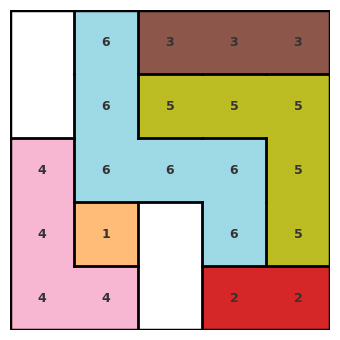

### Answer: 12 x 27 = **324**

In [65]:
solve(sample)

Connectivity & count constraints added (2.1s)
Containment constraints added (41.8s)
Solving...
Solved (6.1s, total 50.0s)



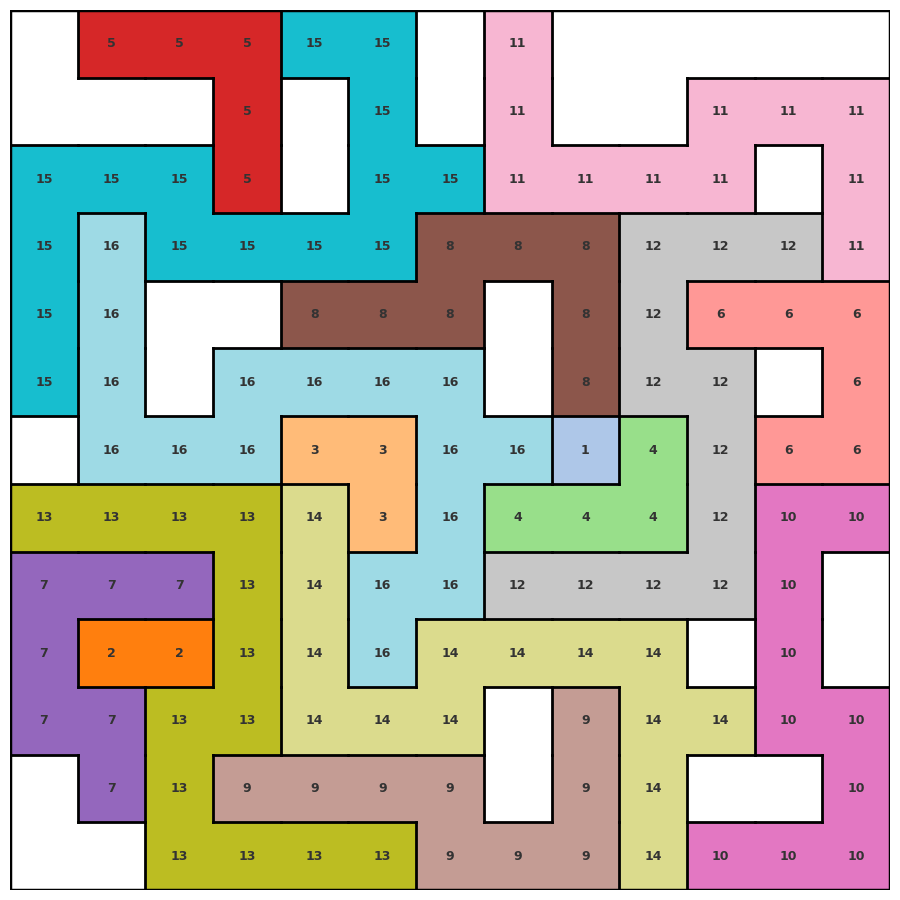

### Answer: 56 x 162 = **9072**

In [66]:
solve(full)